# 16 · The grammar of a chart — what a recipe is, and why `chart_type` is not a chart name

**Use case.** Everything from here to chapter 25 is the half of Langsat that never calls a model: you describe a chart, the server compiles it to SQL and runs it on your data. It costs nothing, it re-aggregates itself every time the data refreshes, and it is the same object the app's chart builder writes. This chapter is the grammar — read it once and the nine chapters after it are vocabulary.

**What you will learn**
1. Read the whole grammar from the server: 24 chart types, your columns, the joins, every bound
2. Why `chart_type` is a **Plotly trace type** and writing `"line"` draws a scatter while reporting success
3. Preview a recipe, then persist **the recipe the preview returned** — not the one you composed
4. The three things a recipe adds for you, so it bounds itself
5. Read a refusal: the reason comes back as a sentence, before anything is saved
6. Prove from the credit ledger that none of it charged

**What this costs.** nothing. Every call in this chapter is free — no model is in the path. The ledger is read at the start and at the end and the difference is printed.

> Every cell below ran for real against `api.langsat.ai` — the outputs are what the API returned. Re-running is safe:
> projects are found by name and reused, and a finished model is not retrained.

In [1]:
import sys, json
sys.path.insert(0, "..")
from _common import connect, get_or_create_project, credits_used, save_metrics, show, fig, fresh_tab, spend, show_recipe
from langsat import charts, viz
import pandas as pd

ls = connect()

signed in as team@langsat.ai · tier team · key 'Langsat_SDK' with 21 scopes


## 1 · The project

Chapters 16–25 all reuse `amazon-reviews-explore` — three tables, uploaded, schema-detected and cleaned by
[chapter 01](../01_setup_and_explore/). Each chapter builds on its own dashboard tab, so they do not collide
and a re-run is the same chapter rather than the chapter plus yesterday's cards.

In [2]:
p = get_or_create_project(ls, "explore", kind="data_analysis")
before = credits_used(ls)

reusing project 5c40e337-9753-4618-a7b3-574419f93c1e (amazon-reviews-explore, status=schema_done)


files already uploaded: ['customer.csv', 'product.csv', 'review.csv'] — skipping the upload
schema already detected — skipping
already cleaned — skipping
project ready: status=schema_done · type=data_analysis · files=['customer.csv', 'product.csv', 'review.csv']


In [3]:
for t in p.tables.list():
    print(f"{t['name']:<9} {t['rows']:>6,} rows × {t['columns']} columns")
sd = p.schema.result()["schema_data"]
print("\nprimary keys :", sd.get("primary_keys"))
print("foreign keys :", sd.get("foreign_keys"))
print("time column  :", sd.get("time_cols") or sd.get("time_columns"))

customer   9,821 rows × 2 columns
product    8,607 rows × 6 columns
review    10,000 rows × 7 columns



primary keys : {'review': '__row_id__', 'product': 'product_id', 'customer': 'customer_id'}
foreign keys : {'review': {'product_id': 'product', 'customer_id': 'customer'}, 'product': {}, 'customer': {}}
time column  : {'review': 'review_time', 'product': None, 'customer': None}


## 2 · Ask the server what it will accept

`builder_capabilities()` is the whole grammar, free, in one call: every chart type with the recipe fragment it
needs and the wells it offers, your columns with the kind the engine sorted them into, the join edges, the saved
measures, the aggregates, the date grains, the filter operators, the recipe keys the validator allows, and every
bound. Read it before you guess — it is the difference between writing a chart and finding out what this project
admits.

In [4]:
tab = fresh_tab(p, "16 · Grammar")
cap = tab.builder_capabilities()
print("keys:", ", ".join(sorted(cap)))
print("\nchart types :", len(cap["chart_types"]))
print("trace types :", sorted(cap["trace_types"]))
print("columns     :", len(cap["columns"]), "·", {k: sum(1 for c in cap["columns"] if c["kind"] == k)
                                                  for k in ("numeric", "text", "datetime", "boolean")})
print("aggregates  :", cap["aggs"])
print("grains      :", cap["grains"])
print("not authorable:", cap["not_authorable"])

keys: agg_names, aggs, attach_enabled, chart_types, columns, composition_detail_enabled, detail_composition_types, filter_ops, grains, joins, limits, measures, multidim_enabled, not_authorable, recipe_keys, small_multiples_enabled, tables, tooltips_enabled, trace_types, transforms, well_flags, xy_scatter_enabled

chart types : 24
trace types : ['bar', 'donut', 'funnel', 'funnelarea', 'heatmap', 'kpi', 'matrix', 'pie', 'scatter', 'treemap']
columns     : 15 · {'numeric': 0, 'text': 14, 'datetime': 1, 'boolean': 0}
aggregates  : [{'id': 'count', 'label': 'Count', 'needs_column': False, 'additive': True, 'kinds': None}, {'id': 'sum', 'label': 'Sum', 'needs_column': True, 'additive': True, 'kinds': ['numeric']}, {'id': 'avg', 'label': 'Average', 'needs_column': True, 'additive': False, 'kinds': ['numeric']}, {'id': 'min', 'label': 'Minimum', 'needs_column': True, 'additive': False, 'kinds': ['numeric', 'datetime']}, {'id': 'max', 'label': 'Maximum', 'needs_column': True, 'additive': False,

`joins` is not a list of edges — it is the schema the server resolved, and the rule it will
hold you to. The SDK has no schema of its own, so a cross-table chart passes the edge explicitly, and this is
where you read it from.

In [5]:
print(json.dumps(cap["joins"], indent=1))

FACT = "review"                                   # the table the measures live on
def edge(dim):
    """The fact→dimension join the server already knows about, in the shape a recipe wants."""
    fk = next(c for c, t in cap["joins"]["foreign_keys"][FACT].items() if t == dim)
    return {"table": dim, "left_column": fk, "right_column": cap["joins"]["primary_keys"][dim], "type": "left"}

TO_PRODUCT = [edge("product")]
TO_CUSTOMER = [edge("customer")]
print("\nreview → product :", TO_PRODUCT)
print("review → customer:", TO_CUSTOMER)

{
 "primary_keys": {
  "review": "__row_id__",
  "product": "product_id",
  "customer": "customer_id"
 },
 "foreign_keys": {
  "review": {
   "product_id": "product",
   "customer_id": "customer"
  },
  "product": {},
  "customer": {}
 },
 "time_cols": {
  "review": "review_time",
  "product": null,
  "customer": null
 },
 "join_rule": "the aggregate must sit on the fact table; only a declared FK\u2192PK edge may be joined; exactly one FK per (fact, dimension) pair"
}

review → product : [{'table': 'product', 'left_column': 'product_id', 'right_column': 'product_id', 'type': 'left'}]
review → customer: [{'table': 'customer', 'left_column': 'customer_id', 'right_column': 'customer_id', 'type': 'left'}]


The six booleans are **feature flags on this server**, and they are why a notebook reads the capabilities
instead of assuming. On langsat.ai today `xy_scatter_enabled` is off, so 23 of the 24 chart types run there and
`charts.scatter` comes back refused — with that reason, which is the point.

In [6]:
print({k: v for k, v in cap.items() if k.endswith("_enabled")})
print("\nbounds:")
for k, v in sorted(cap["limits"].items()):
    print(f"  {k:<26} {v}")

{'attach_enabled': True, 'multidim_enabled': True, 'small_multiples_enabled': True, 'tooltips_enabled': False, 'xy_scatter_enabled': False, 'composition_detail_enabled': False}

bounds:
  max_composition_leaves     200
  max_filter_values          200
  max_filters                8
  max_heatmap_cells          7500
  max_heatmap_series         50
  max_legend_series          20
  max_relative_days          3650
  max_series_traces          20
  max_tooltips               3
  max_top_n                  5000
  max_values                 4
  max_x_categories           5000
  max_xy_points              2000


## 3 · `chart_type` is a Plotly TRACE type

This is the one fact worth stopping for. A recipe's `chart_type` is not the name of a chart — it is the name of a
**Plotly trace**, and Plotly has no `line` trace and no `area` trace. A line is a `scatter` with `mode: "lines"`;
an area is that plus `fill: "tozeroy"`; a clustered column is a `bar` with `barmode: "group"` in its layout.

The engine validates by **blocklist**. So a hand-written `chart_type: "line"` is not refused — it passes, Plotly
falls back to a default scatter, and the API reports success. You get a chart. It is the wrong chart.

`langsat.charts` exists so you never have to know that: one function per chart type, each generated from the same
declaration the app and the server read.

In [7]:
print(f"{len(charts.BY_ID)} constructors\n")
for cid in ("column", "bar", "line", "area", "stacked_column_100", "donut", "dot", "combo"):
    print(f"  charts.{cid:<20} → {json.dumps(charts.TRACES[cid], sort_keys=True)}")

24 constructors

  charts.column               → {"chart_type": "bar"}
  charts.bar                  → {"chart_type": "bar", "orientation": "h"}
  charts.line                 → {"chart_type": "scatter", "mode": "lines"}
  charts.area                 → {"chart_type": "scatter", "fill": "tozeroy", "mode": "lines"}
  charts.stacked_column_100   → {"chart_type": "bar", "render_layout": {"barmode": "stack", "barnorm": "percent"}}
  charts.donut                → {"chart_type": "donut", "hole": 0.4}
  charts.dot                  → {"chart_type": "scatter", "mode": "markers"}
  charts.combo                → {"chart_type": "bar"}


In [8]:
# The same chart, written both ways.
hand_written = {"tables": ["review"], "chart_type": "line",
                "group_by": [{"column": "review_time", "transform": "to_year"}],
                "measure": {"agg": "count"}}
generated = charts.line(axis=charts.date("review.review_time", "year"),
                        value=charts.count(), tables=["review"])
print("hand-written chart_type:", hand_written["chart_type"])
print("what a line actually is :", generated["chart_type"], "+ mode", repr(generated["mode"]))
print("\nis 'line' a trace the server accepts? ", "line" in cap["trace_types"])

hand-written chart_type: line
what a line actually is : scatter + mode 'lines'

is 'line' a trace the server accepts?  False


## 4 · Preview, then persist what the preview returned

`preview_chart()` renders a recipe without saving it — free, and it answers two questions at once: does this
recipe work, and what does the server turn it into. It **normalises**: it mints bin labels, defaults the chart
type, may pin a legend rollup. Persisting your own copy instead of the returned one is how a saved card ends up
differing from the one you looked at.

In [9]:
recipe = charts.column(axis="review.rating", value=charts.count(), tables=["review"])
print("what you wrote:"); show_recipe(recipe)
pv = tab.preview_chart(recipe)
print(f"\nok={pv['ok']} · n_groups={pv['n_groups']} · traces={[d['type'] for d in pv['spec']['data']]}")
print("\nwhat the server returned:"); show_recipe(pv["recipe"])

what you wrote:
  tables         ["review"]
  chart_type     "bar"
  group_by       [{"column": "rating"}]
  measure        {"agg": "count"}
  order_by       {"dir": "desc", "limit": 50}



ok=True · n_groups=5 · traces=['bar']

what the server returned:
  tables         ["review"]
  chart_type     "bar"
  group_by       [{"column": "rating"}]
  measure        {"agg": "count"}
  order_by       {"dir": "desc", "limit": 50}


In [10]:
chart = tab.add_chart(pv["recipe"], title="Reviews by rating")
print(chart.id, "·", chart.title)
print("\nthe numbers behind it:")
print(dict(zip(pv["spec"]["data"][0]["x"], pv["spec"]["data"][0]["y"])))

w-4f2bb9fb · Reviews by rating

the numbers behind it:
{5: 6311, 4: 2199, 3: 850, 2: 358, 1: 282}


## 5 · The three things a recipe adds for you

A recipe should bound itself, so the SDK writes three rules the app writes too:

1. **A categorical axis always carries `order_by.limit`.** Without it a group-by over 6,469 brands returns 6,469
   rows to draw on an axis a few hundred pixels wide. A drill re-runs uncapped, so the cap costs nothing where it
   matters.
2. **A date axis always carries a grain.** A raw timestamp is one category per instant.
3. **The aggregate sits on the fact table.** Across a join a dimension value repeats once per joined fact row, so
   summing it multiplies.

Rule 2 is the one that bites quietly. The SDK has no schema — it cannot tell a date column from a text one by its
name — so you say so with `charts.date(column, grain)`.

In [11]:
no_grain = charts.column(axis="review.review_time", value=charts.count(), tables=["review"])
a = tab.preview_chart(no_grain)
print(f"a raw date axis  → n_groups={a['n_groups']:,} and the chart draws {len(a['spec']['data'][0]['x'])} of them")
print("                   order_by:", no_grain.get("order_by"))
with_grain = charts.line(axis=charts.date("review.review_time", "year"), value=charts.count(), tables=["review"])
b = tab.preview_chart(with_grain)
print(f"charts.date(…, 'year') → n_groups={b['n_groups']} and the chart draws {len(b['spec']['data'][0]['x'])}")
print("                   order_by:", with_grain.get("order_by"), "· grain:", with_grain["group_by"][0]["transform"])

a raw date axis  → n_groups=2,772 and the chart draws 50 of them
                   order_by: {'dir': 'desc', 'limit': 50}


charts.date(…, 'year') → n_groups=11 and the chart draws 11
                   order_by: None · grain: to_year


## 6 · A refusal is a sentence

Two kinds, and both arrive before anything is saved. The SDK refuses **locally**, with the app's own code, what it
can decide without the server — a chart with no measure, a count given a column, bins that do not ascend. The
server refuses what needs the schema, and says why.

In [12]:
from langsat._charts_core import RecipeError

def refuse(label, fn):
    try:
        fn(); print(f"  {label:<26} (not refused)")
    except RecipeError as e: print(f"  {label:<26} {e}")
    except TypeError as e:   print(f"  {label:<26} TypeError: {e}")

print("refused locally, by the app's own rules:")
refuse("a chart with no value",  lambda: charts.column(axis="review.rating", tables=["review"]))
refuse("a grain that is not one", lambda: charts.date("review.review_time", "hour"))
refuse("bins that descend",      lambda: charts.histogram(axis="product.price", edges=[50, 10, 0], tables=["product"]))
refuse("a combo with a legend",  lambda: charts.combo(axis="review.rating", series="review.verified",
                                                      value=charts.count(), value2=charts.avg("review.rating"), tables=["review"]))
refuse("count given a column",   lambda: charts.count("review.rating"))

refused locally, by the app's own rules:
  a chart with no value      [pickSummary] every chart needs a value — e.g. charts.sum('t.amount')
  a grain that is not one    [badGrain] 'hour' is not a grain — use one of year, quarter, month, week, date
  bins that descend          [binEdgesNotAscending] bin edges must ascend strictly: [50.0, 10.0, 0.0]
  a combo with a legend      [multiValueNoLegend] a combo cannot also have a legend — each value would pick its own top-K keep-set, so the two halves would describe different rows
  count given a column       TypeError: count() takes 0 positional arguments but 1 was given


The last one is a `TypeError` rather than a refusal, and that is the design: `charts.count()` counts
**rows** and takes no column at all, so the mistake is caught by the signature before any rule runs. The thing
you meant is `charts.count_distinct(column)`.

The server refuses what needs the schema — and says why, in a sentence, before anything is saved.

In [13]:
from langsat.errors import Refused

def server_refuse(label, recipe):
    try:
        pv = tab.preview_chart(recipe); print(f"  {label:<26} (not refused) n_groups={pv['n_groups']}")
    except Refused as e:
        print(f"  {label:<26} {str(e).replace('[200 refused] ', '')}")

server_refuse("two tables, no join",
              charts.column(axis="product.category", value=charts.count(), tables=["review", "product"]))
server_refuse("aggregate on the dimension",
              charts.bar(axis="product.category", value=charts.avg("product.price"),
                         tables=["review", "product"], joins=TO_PRODUCT, top_n=12))
server_refuse("a chart type this server has off",
              charts.scatter(details="product.product_id", x=charts.avg("review.rating"),
                             y=charts.count(), tables=["review", "product"], joins=TO_PRODUCT))

  two tables, no join        a multi-table chart needs an explicit fact-to-dimension relationship — pick fields from one table


  aggregate on the dimension those tables cannot be combined: measure avg(product.price) aggregates a dimension column on 'product' across a fan-out join (would double-count) — fail-closed to the analytical lane


  a chart type this server has off xy scatter is not enabled (recipe_xy_scatter)


Three refusals, three different rules. The second is rule 3 enforced: `product.price` lives on the
**dimension** table, so averaging it across the join would average it once per *review* rather than once per
product — the engine calls that a fan-out and fails closed rather than returning a plausible number. The third is
a feature flag, and the reason names it, which is how you tell "this server has it off" from "you wrote it wrong".

The chart that *is* right puts the aggregate on the fact table and passes the edge.

n_groups=426 · drawn=12


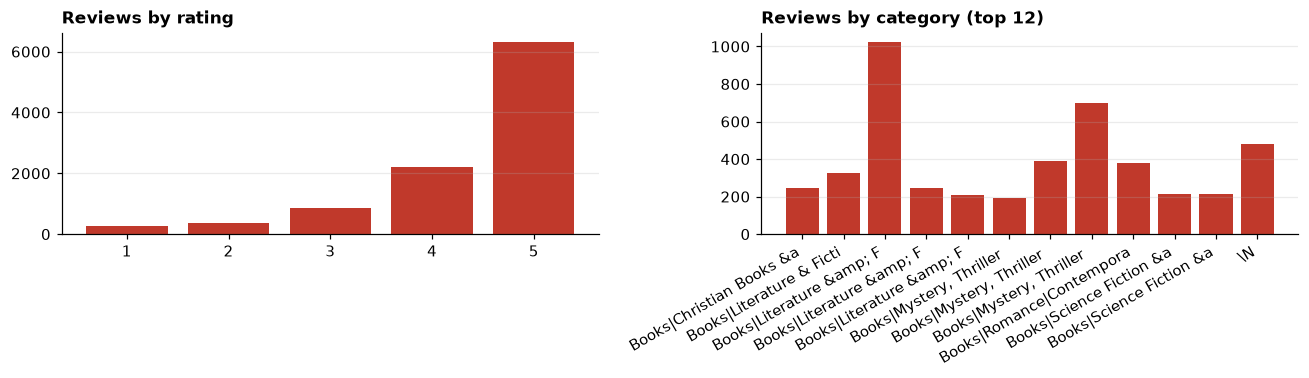

In [14]:
ok = charts.column(axis="product.category", value=charts.count(),
                   tables=["review", "product"], joins=TO_PRODUCT, top_n=12)
pv2 = tab.preview_chart(ok)
tab.add_chart(pv2["recipe"], title="Reviews by category (top 12)")
print(f"n_groups={pv2['n_groups']} · drawn={len(pv2['spec']['data'][0]['x'])}")
fig(viz.draw_tab(tab, cols=2))

## 7 · What it cost

Nothing. Not the capabilities call, not the previews, not the refusals, not the two saved cards. A recipe is
compiled to SQL and run against your data with no model in the path — which is the claim the rest of this book
rests on, so it is measured rather than asserted.

In [15]:
charged = credits_used(ls) - before
print(f"credits charged by this notebook: {charged}")
save_metrics(".", {"notebook": "16_chart_grammar", "task": "the recipe grammar · 24 chart types, preview → persist, refusals",
                   "model": "—", "project_id": p.id, "credits_charged_this_run": charged,
                   "headline": {"chart_types": len(cap["chart_types"]), "trace_types": len(cap["trace_types"]),
                                "columns": len(cap["columns"]), "not_authorable": len(cap["not_authorable"]),
                                "xy_scatter_enabled": cap["xy_scatter_enabled"],
                                "raw_date_groups": a["n_groups"], "raw_date_drawn": len(a["spec"]["data"][0]["x"])}})

credits charged by this notebook: 0
wrote results/metrics.json


PosixPath('results/metrics.json')

## Where to go next

- [17 · Compare](../17_compare/) — the fifteen bar and column forms, and when each one is the honest choice
- [18 · Trend](../18_trend/) — time on the axis, the five grains, and the filter that freezes
- `help(langsat.charts)` — the constructors, each with the fragment it emits